<a href="https://colab.research.google.com/github/sanjanasrinivas22/6thSem-ML-Lab/blob/main/1BM23CS301_Lab_5_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder

data=pd.read_csv("iris (1) (1).csv")

X=data.iloc[:,:-1]
y=data.iloc[:,-1]

le=LabelEncoder()
y=le.fit_transform(y)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix

data=pd.read_csv("diabetes.csv")

X=data.drop("Outcome",axis=1)
y=data["Outcome"]

scaler=StandardScaler()
X=scaler.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.6883116883116883
Confusion Matrix:
 [[79 20]
 [28 27]]


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt

data=pd.read_csv("heart.csv")

X=data.drop("target",axis=1)
y=data["target"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scores=[]

for k in range(1,21):
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    scores.append(model.score(X_test,y_test))

best_k=scores.index(max(scores))+1

model=KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("Best K:",best_k)
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification Report:\n",classification_report(y_test,y_pred))

Best K: 11
Accuracy: 0.7540983606557377
Confusion Matrix:
 [[20  9]
 [ 6 26]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.74      0.81      0.78        32

    accuracy                           0.75        61
   macro avg       0.76      0.75      0.75        61
weighted avg       0.76      0.75      0.75        61



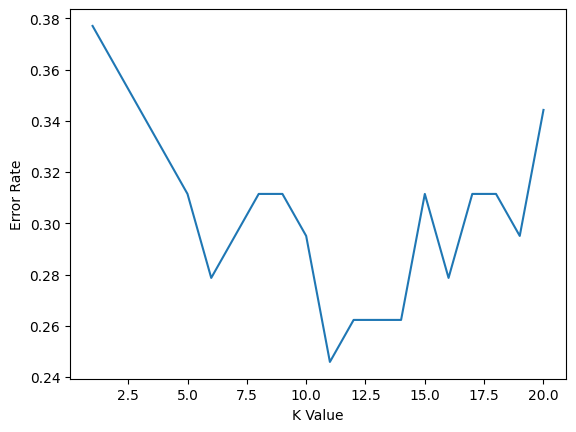

In [4]:
import matplotlib.pyplot as plt
error=[]

for k in range(1,21):
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    error.append(1-accuracy_score(y_test,pred))

plt.plot(range(1,21),error)
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.show()

In [8]:
import csv
import math
import random

def load_dataset(filename):
    dataset=[]
    with open(filename,'r') as file:
        csv_reader=csv.reader(file)
        next(csv_reader)
        for row in csv_reader:
            row[0]=float(row[0])
            row[1]=float(row[1])
            row[2]=float(row[2])
            row[3]=float(row[3])
            dataset.append(row)
    return dataset

def split_dataset(dataset,ratio):
    train_size=int(len(dataset)*ratio)
    train=[]
    dataset_copy=list(dataset)
    while len(train)<train_size:
        index=random.randrange(len(dataset_copy))
        train.append(dataset_copy.pop(index))
    return train,dataset_copy

def distance(row1,row2):
    d=0
    for i in range(len(row1)-1):
        d+=(row1[i]-row2[i])**2
    return math.sqrt(d)

def neighbors(train,test_row,k):
    dist=[]
    for row in train:
        d=distance(test_row,row)
        dist.append((row,d))
    dist.sort(key=lambda x:x[1])
    return [dist[i][0] for i in range(k)]

def predict(train,test_row,k):
    n=neighbors(train,test_row,k)
    output=[row[-1] for row in n]
    return max(set(output),key=output.count)

def accuracy(actual,predicted):
    c=0
    for i in range(len(actual)):
        if actual[i]==predicted[i]:
            c+=1
    return c/len(actual)*100

dataset=load_dataset("iris (1) (1).csv")

train,test=split_dataset(dataset,0.8)

pred=[]
actual=[]

k=3

for row in test:
    result=predict(train,row,k)
    pred.append(result)
    actual.append(row[-1])

print("Accuracy:",accuracy(actual,pred))

Accuracy: 96.66666666666667


In [5]:
import csv
import math
import random

def load_dataset(filename):
    dataset=[]
    with open(filename,'r') as file:
        csv_reader=csv.reader(file)
        next(csv_reader)
        for row in csv_reader:
            row=[float(i) for i in row]
            dataset.append(row)
    return dataset

def split_dataset(dataset,ratio):
    train_size=int(len(dataset)*ratio)
    train=[]
    dataset_copy=list(dataset)
    while len(train)<train_size:
        index=random.randrange(len(dataset_copy))
        train.append(dataset_copy.pop(index))
    return train,dataset_copy

def distance(row1,row2):
    d=0
    for i in range(len(row1)-1):
        d+=(row1[i]-row2[i])**2
    return math.sqrt(d)

def neighbors(train,test_row,k):
    dist=[]
    for row in train:
        d=distance(test_row,row)
        dist.append((row,d))
    dist.sort(key=lambda x:x[1])
    return [dist[i][0] for i in range(k)]

def predict(train,test_row,k):
    n=neighbors(train,test_row,k)
    output=[row[-1] for row in n]
    return max(set(output),key=output.count)

def accuracy(actual,predicted):
    c=0
    for i in range(len(actual)):
        if actual[i]==predicted[i]:
            c+=1
    return c/len(actual)*100

dataset=load_dataset("diabetes.csv")

train,test=split_dataset(dataset,0.8)

pred=[]
actual=[]

k=5

for row in test:
    result=predict(train,row,k)
    pred.append(result)
    actual.append(row[-1])

print("Accuracy:",accuracy(actual,pred))

Accuracy: 76.62337662337663


In [6]:
import csv
import math
import random

def load_dataset(filename):
    dataset=[]
    with open(filename,'r') as file:
        csv_reader=csv.reader(file)
        next(csv_reader)
        for row in csv_reader:
            row=[float(i) for i in row]
            dataset.append(row)
    return dataset

def split_dataset(dataset,ratio):
    train_size=int(len(dataset)*ratio)
    train=[]
    dataset_copy=list(dataset)
    while len(train)<train_size:
        index=random.randrange(len(dataset_copy))
        train.append(dataset_copy.pop(index))
    return train,dataset_copy

def distance(row1,row2):
    d=0
    for i in range(len(row1)-1):
        d+=(row1[i]-row2[i])**2
    return math.sqrt(d)

def neighbors(train,test_row,k):
    dist=[]
    for row in train:
        d=distance(test_row,row)
        dist.append((row,d))
    dist.sort(key=lambda x:x[1])
    return [dist[i][0] for i in range(k)]

def predict(train,test_row,k):
    n=neighbors(train,test_row,k)
    output=[row[-1] for row in n]
    return max(set(output),key=output.count)

def accuracy(actual,predicted):
    c=0
    for i in range(len(actual)):
        if actual[i]==predicted[i]:
            c+=1
    return c/len(actual)*100

dataset=load_dataset("heart.csv")

train,test=split_dataset(dataset,0.8)

pred=[]
actual=[]

k=5

for row in test:
    result=predict(train,row,k)
    pred.append(result)
    actual.append(row[-1])

print("Accuracy:",accuracy(actual,pred))

Accuracy: 65.57377049180327
